In [2]:
import pandas as pd

df = pd.read_csv('/content/online_retail.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print("Shape:", df.shape)
print("\nColumn Info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

df.head()

Shape: (141049, 8)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141049 entries, 0 to 141048
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    141049 non-null  object 
 1   StockCode    141049 non-null  object 
 2   Description  140586 non-null  object 
 3   Quantity     141049 non-null  int64  
 4   InvoiceDate  141049 non-null  object 
 5   UnitPrice    141048 non-null  float64
 6   CustomerID   96535 non-null   float64
 7   Country      141048 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 8.6+ MB

Missing values:
InvoiceNo          0
StockCode          0
Description      463
Quantity           0
InvoiceDate        0
UnitPrice          1
CustomerID     44514
Country            1
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Drop rows with missing CustomerID — can't segment unknown customers
df = df.dropna(subset=['CustomerID'])

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove cancelled orders (Quantity < 0) and zero/negative prices — not real purchases
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Create a TotalPrice column (Quantity x UnitPrice) — needed for Monetary value
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (94090, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [5]:
import datetime as dt

# Set a reference date (one day after the last transaction in the dataset)
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Build RFM table per customer
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                         # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,73,1,77183.60
12347.0,64,2,1187.18
12348.0,66,2,1120.24
12350.0,57,1,334.40
12352.0,9,5,1561.81


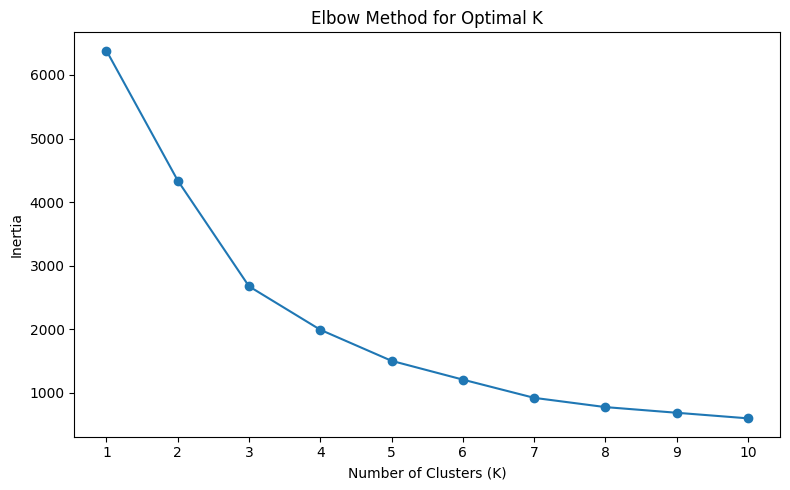

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Standardize the RFM values (important — clustering is sensitive to scale)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Elbow method: try different numbers of clusters (K) and plot the "inertia"
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

In [7]:
# Apply K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Check how many customers fall into each cluster
print(rfm['Cluster'].value_counts())

rfm.head()

Cluster
1    1341
0     760
3      20
2       6
Name: count, dtype: int64


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,73,1,77183.60,2
12347.0,64,2,1187.18,0
12348.0,66,2,1120.24,0
12350.0,57,1,334.40,0
12352.0,9,5,1561.81,1


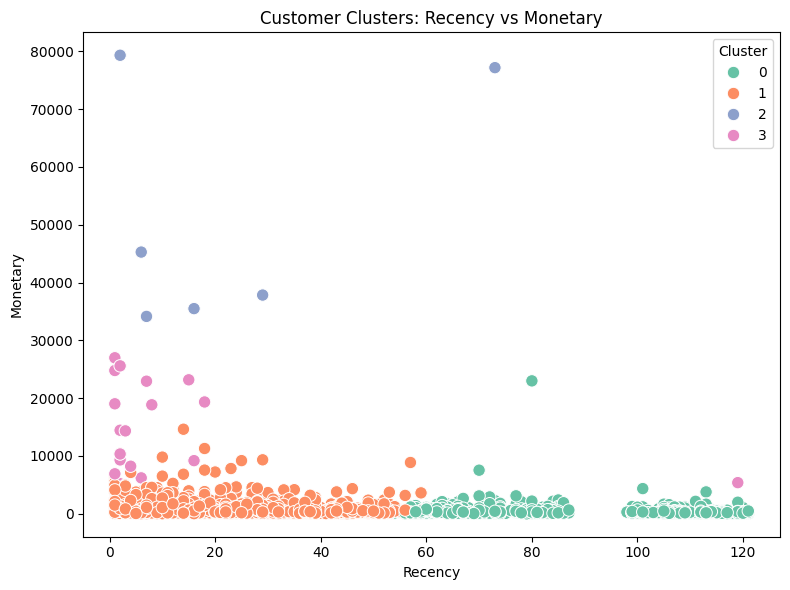

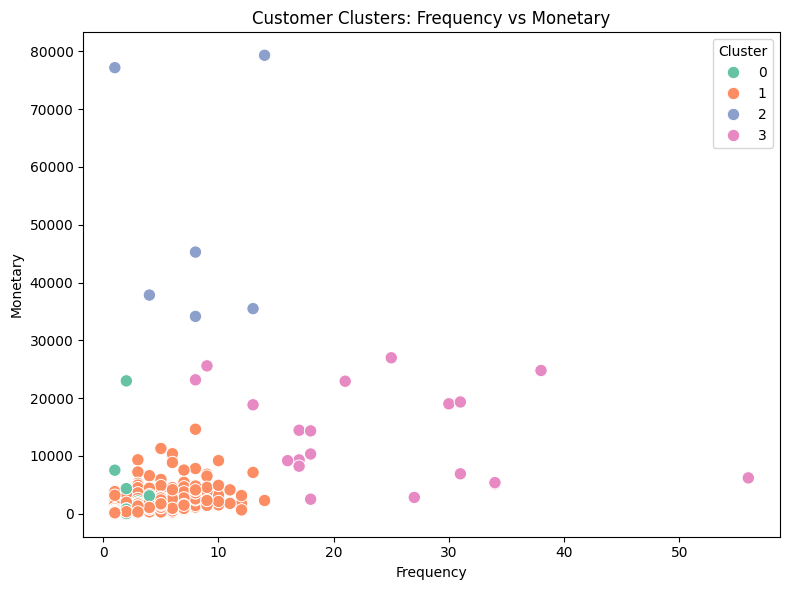

         Recency  Frequency  Monetary  Customer Count
Cluster                                              
0           89.6        1.3     462.5             760
1           22.5        2.4     924.8            1341
2           22.2        8.0   51546.8               6
3           10.6       23.9   13786.1              20


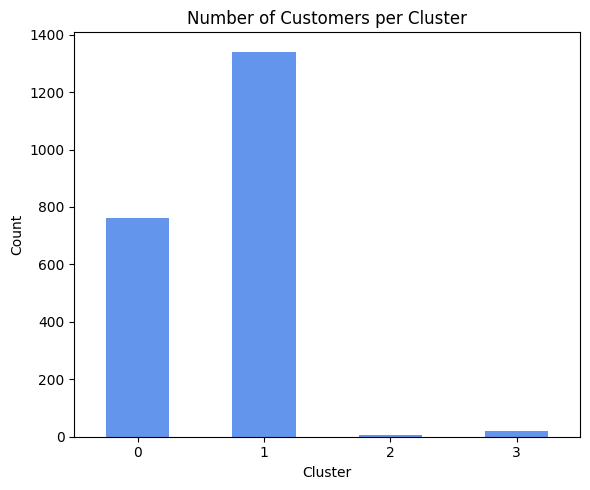

In [8]:
import seaborn as sns

# Scatter plot: Recency vs Monetary, colored by cluster
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set2', s=80)
plt.title('Customer Clusters: Recency vs Monetary')
plt.tight_layout()
plt.show()

# Scatter plot: Frequency vs Monetary, colored by cluster
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set2', s=80)
plt.title('Customer Clusters: Frequency vs Monetary')
plt.tight_layout()
plt.show()

# Profile each cluster: average R, F, M per cluster
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1)
cluster_profile['Customer Count'] = rfm['Cluster'].value_counts()
print(cluster_profile)

# Bar chart: number of customers per cluster
plt.figure(figsize=(6,5))
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', color='cornflowerblue')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Cluster Profiles & Marketing Recommendations

**Cluster 0 — At Risk / Inactive Customers (760 customers)**
Longest time since last purchase (~90 days) and lowest order frequency.
These customers are drifting away.
→ Recommendation: Win-back email campaigns with special discounts to
re-engage before they churn completely.

**Cluster 1 — Regular Customers (1,341 customers)**
The largest segment — recently active with moderate spending and frequency.
→ Recommendation: Nurture with loyalty points or bundle offers to push
them toward higher-value purchases.

**Cluster 2 — VIP Whales (6 customers)**
An extremely small group with massive average spend (~$51,500). These are
the company's most valuable customers by far.
→ Recommendation: Assign dedicated account management, offer exclusive
early access to new products, and prioritize retention at all costs.

**Cluster 3 — Loyal High-Frequency Buyers (20 customers)**
Most recently active and by far the most frequent purchasers (~24 orders each).
→ Recommendation: Reward with a formal loyalty/VIP program, since they are
highly engaged and likely to respond well to referral incentives.

## Conclusion

K-Means clustering (K=4) successfully segmented the customer base into four
distinct groups based on Recency, Frequency, and Monetary value. The analysis
revealed a small but extremely high-value "VIP Whale" segment and a loyal
high-frequency segment, both disproportionately valuable despite their small
size, alongside two larger segments of regular and at-risk customers. These
insights enable targeted marketing strategies tailored to each group's
behavior and value to the business.